In [1]:
import numpy as np
import pandas as pd

In [4]:
## reading usda file
data = pd.read_csv("usda_farm_indices.csv")
data.head(10)

,Year,Attribute,Value
0,1948,Total agricultural output,0.362833
1,1948,Livestock and products output: Total 1/,0.437903
2,1948,Livestock and products output: Meat animals,0.562957
3,1948,Livestock and products output: Dairy,0.448529
4,1948,Livestock and products output: Poultry and eggs,0.129304
5,1948,Crops output: Total,0.338529
6,1948,Crops output: Food grains,0.524309
7,1948,Crops output: Feed crops,0.392067
8,1948,Crops output: Oil crops,0.110668
9,1948,Crops output: Vegetables and melons,0.397223


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2130 entries, 0 to 2129
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       2130 non-null   int64  
 1   Attribute  2130 non-null   object 
 2   Value      2130 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 50.1+ KB


In [6]:
data["Year"].unique()

array([1948, 1949, 1950, 1951, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
       1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019])

In [7]:
data["Attribute"].unique()

array(['Total agricultural output',
       'Livestock and products output: Total 1/',
       'Livestock and products output: Meat animals',
       'Livestock and products output: Dairy',
       'Livestock and products output: Poultry and eggs',
       'Crops output: Total', 'Crops output: Food grains',
       'Crops output: Feed crops', 'Crops output: Oil crops',
       'Crops output: Vegetables and melons',
       'Crops output: Fruits and nuts', 'Crops output: Other crops 2/',
       'Farm-related output 3/', 'Farm inputs: Total ',
       'Capital inputs: Total', 'Capital inputs: Durable equipment',
       'Capital inputs: Service buildings', 'Capital inputs: Land',
       'Capital inputs: Inventories', 'Labor inputs: Total',
       'Labor inputs: Hired labor',
       'Labor inputs: Self-employed and unpaid family',
       'Intermediate inputs: Total', 'Intermediate inputs: Feed and seed',
       'Intermediate inputs: Energy',
       'Intermediate inputs: Fertilizer and lime',
      

In [12]:
#cleaning the Attribute data
data["Attribute"] = [attribute.replace("1/","").replace("2/","").replace("3/","").strip() for attribute in data["Attribute"]]
#print(data["Attribute"])
attributes = data["Attribute"].unique()
#print(attributes)

In [13]:
# retrieving the specific value of the attribute

data[data["Attribute"] == attributes[0]].head()

,Year,Attribute,Value
0,1948,Total agricultural output,0.362833
30,1949,Total agricultural output,0.357259
60,1950,Total agricultural output,0.348639
90,1951,Total agricultural output,0.364145
120,1953,Total agricultural output,0.380998


In [ ]:
#we can use to convert the dataframe into value table using pivot
pivot_data = data.pivot(index= "Year",columns="Attribute",values="Value")
pivot_data.head()

Attribute,Capital inputs: Durable equipment,Capital inputs: Inventories,Capital inputs: Land,Capital inputs: Service buildings,Capital inputs: Total,Crops output: Feed crops,Crops output: Food grains,Crops output: Fruits and nuts,Crops output: Oil crops,Crops output: Other crops,...,Intermediate inputs: Total,Labor inputs: Hired labor,Labor inputs: Self-employed and unpaid family,Labor inputs: Total,Livestock and products output: Dairy,Livestock and products output: Meat animals,Livestock and products output: Poultry and eggs,Livestock and products output: Total,Total agricultural output,Total factor productivity (TFP)
Year,,,,,,,,,,,,,,,,,,,,,
1948,0.467550,0.692027,1.369041,0.886676,1.120363,0.392067,0.524309,0.310912,0.110668,0.409471,...,0.431257,2.999098,4.570501,3.974612,0.448529,0.562957,0.129304,0.437903,0.362833,0.383332
1949,0.551742,0.748731,1.373723,0.925152,1.140866,0.360510,0.450339,0.275063,0.105840,0.450250,...,0.445904,2.786415,4.546308,3.878824,0.468620,0.582993,0.148074,0.440938,0.357259,0.372391
1950,0.636630,0.738851,1.376958,0.955876,1.169548,0.369673,0.419780,0.273999,0.107492,0.347430,...,0.454706,2.904928,4.236456,3.731842,0.472827,0.597969,0.158971,0.448577,0.348639,0.361446
1951,0.710515,0.756921,1.378356,0.983986,1.192800,0.357164,0.414267,0.299867,0.112389,0.450895,...,0.475389,2.804684,4.066649,3.588449,0.465135,0.630788,0.170449,0.466605,0.364145,0.371730
1953,0.806329,0.820665,1.374288,1.035700,1.221481,0.368851,0.488033,0.303515,0.113453,0.465445,...,0.481813,2.662123,3.789422,3.362526,0.500524,0.659016,0.178877,0.489349,0.380998,0.389327


<Axes: xlabel='Year'>

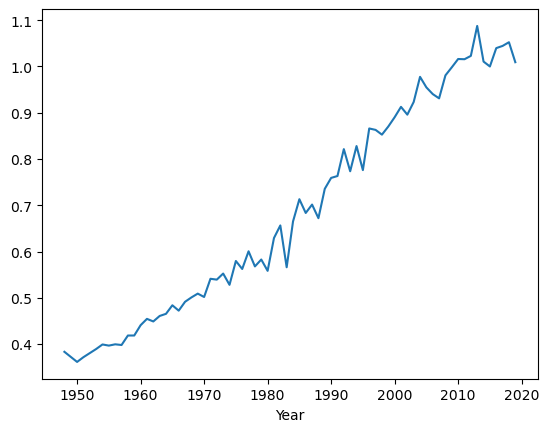

In [21]:
#we can also plot using pandas

pivot_data["Total factor productivity (TFP)"].plot()

In [ ]:
# To isolate specific index value use loc() using index name 
pivot_data.loc[1950:1990] # inclusive

Attribute,Capital inputs: Durable equipment,Capital inputs: Inventories,Capital inputs: Land,Capital inputs: Service buildings,Capital inputs: Total,Crops output: Feed crops,Crops output: Food grains,Crops output: Fruits and nuts,Crops output: Oil crops,Crops output: Other crops,...,Intermediate inputs: Total,Labor inputs: Hired labor,Labor inputs: Self-employed and unpaid family,Labor inputs: Total,Livestock and products output: Dairy,Livestock and products output: Meat animals,Livestock and products output: Poultry and eggs,Livestock and products output: Total,Total agricultural output,Total factor productivity (TFP)
Year,,,,,,,,,,,,,,,,,,,,,
1950,0.636630,0.738851,1.376958,0.955876,1.169548,0.369673,0.419780,0.273999,0.107492,0.347430,...,0.454706,2.904928,4.236456,3.731842,0.472827,0.597969,0.158971,0.448577,0.348639,0.361446
1951,0.710515,0.756921,1.378356,0.983986,1.192800,0.357164,0.414267,0.299867,0.112389,0.450895,...,0.475389,2.804684,4.066649,3.588449,0.465135,0.630788,0.170449,0.466605,0.364145,0.371730
1953,0.806329,0.820665,1.374288,1.035700,1.221481,0.368851,0.488033,0.303515,0.113453,0.465445,...,0.481813,2.662123,3.789422,3.362526,0.500524,0.659016,0.178877,0.489349,0.380998,0.389327
1954,0.847383,0.803575,1.368018,1.058393,1.232198,0.381831,0.428479,0.316886,0.119310,0.425991,...,0.456726,2.509897,3.775568,3.295194,0.513048,0.685004,0.188597,0.503202,0.380785,0.399189
1955,0.862413,0.824431,1.357938,1.079194,1.234368,0.402359,0.404737,0.332644,0.138262,0.434091,...,0.496898,2.466678,3.683562,3.221859,0.520769,0.709062,0.185729,0.513095,0.391252,0.396711
1956,0.873080,0.836250,1.344321,1.096824,1.233537,0.396013,0.422993,0.327825,0.150385,0.409459,...,0.513229,2.252523,3.489978,3.019607,0.534774,0.698535,0.207169,0.525025,0.393600,0.399502
1957,0.860423,0.814399,1.328591,1.109968,1.220187,0.433224,0.400668,0.335504,0.145213,0.345656,...,0.529596,2.160936,3.189937,2.799912,0.539649,0.665830,0.211919,0.513434,0.389331,0.398013
1958,0.846848,0.840619,1.313282,1.121607,1.207423,0.457070,0.591336,0.315186,0.174290,0.362938,...,0.551163,2.176793,2.965910,2.669006,0.538813,0.676294,0.225070,0.518456,0.411026,0.418505
1959,0.850053,0.871198,1.301565,1.131774,1.203104,0.461834,0.472734,0.342110,0.159291,0.435320,...,0.585910,2.124607,2.969396,2.650625,0.537755,0.712665,0.233017,0.534951,0.422037,0.418540


In [29]:
#iloc() using list of index in python not names
pivot_data.iloc[2:11]

Attribute,Capital inputs: Durable equipment,Capital inputs: Inventories,Capital inputs: Land,Capital inputs: Service buildings,Capital inputs: Total,Crops output: Feed crops,Crops output: Food grains,Crops output: Fruits and nuts,Crops output: Oil crops,Crops output: Other crops,...,Intermediate inputs: Total,Labor inputs: Hired labor,Labor inputs: Self-employed and unpaid family,Labor inputs: Total,Livestock and products output: Dairy,Livestock and products output: Meat animals,Livestock and products output: Poultry and eggs,Livestock and products output: Total,Total agricultural output,Total factor productivity (TFP)
Year,,,,,,,,,,,,,,,,,,,,,
1950,0.636630,0.738851,1.376958,0.955876,1.169548,0.369673,0.419780,0.273999,0.107492,0.347430,...,0.454706,2.904928,4.236456,3.731842,0.472827,0.597969,0.158971,0.448577,0.348639,0.361446
1951,0.710515,0.756921,1.378356,0.983986,1.192800,0.357164,0.414267,0.299867,0.112389,0.450895,...,0.475389,2.804684,4.066649,3.588449,0.465135,0.630788,0.170449,0.466605,0.364145,0.371730
1953,0.806329,0.820665,1.374288,1.035700,1.221481,0.368851,0.488033,0.303515,0.113453,0.465445,...,0.481813,2.662123,3.789422,3.362526,0.500524,0.659016,0.178877,0.489349,0.380998,0.389327
1954,0.847383,0.803575,1.368018,1.058393,1.232198,0.381831,0.428479,0.316886,0.119310,0.425991,...,0.456726,2.509897,3.775568,3.295194,0.513048,0.685004,0.188597,0.503202,0.380785,0.399189
1955,0.862413,0.824431,1.357938,1.079194,1.234368,0.402359,0.404737,0.332644,0.138262,0.434091,...,0.496898,2.466678,3.683562,3.221859,0.520769,0.709062,0.185729,0.513095,0.391252,0.396711
1956,0.873080,0.836250,1.344321,1.096824,1.233537,0.396013,0.422993,0.327825,0.150385,0.409459,...,0.513229,2.252523,3.489978,3.019607,0.534774,0.698535,0.207169,0.525025,0.393600,0.399502
1957,0.860423,0.814399,1.328591,1.109968,1.220187,0.433224,0.400668,0.335504,0.145213,0.345656,...,0.529596,2.160936,3.189937,2.799912,0.539649,0.665830,0.211919,0.513434,0.389331,0.398013
1958,0.846848,0.840619,1.313282,1.121607,1.207423,0.457070,0.591336,0.315186,0.174290,0.362938,...,0.551163,2.176793,2.965910,2.669006,0.538813,0.676294,0.225070,0.518456,0.411026,0.418505
1959,0.850053,0.871198,1.301565,1.131774,1.203104,0.461834,0.472734,0.342110,0.159291,0.435320,...,0.585910,2.124607,2.969396,2.650625,0.537755,0.712665,0.233017,0.534951,0.422037,0.418540


In [33]:
#get the value of 1950 in the column with total in the column

total = [col for col in pivot_data.columns if "Total" in col]
pivot_data.loc[1950:1959,total]

Attribute,Capital inputs: Total,Crops output: Total,Farm inputs: Total,Intermediate inputs: Total,Labor inputs: Total,Livestock and products output: Total,Total agricultural output,Total factor productivity (TFP)
Year,,,,,,,,
1950,1.169548,0.308353,0.964567,0.454706,3.731842,0.448577,0.348639,0.361446
1951,1.192800,0.325324,0.979596,0.475389,3.588449,0.466605,0.364145,0.371730
1953,1.221481,0.339858,0.978607,0.481813,3.362526,0.489349,0.380998,0.389327
1954,1.232198,0.332601,0.953897,0.456726,3.295194,0.503202,0.380785,0.399189
1955,1.234368,0.344601,0.986239,0.496898,3.221859,0.513095,0.391252,0.396711
1956,1.233537,0.341104,0.985226,0.513229,3.019607,0.525025,0.393600,0.399502
1957,1.220187,0.338806,0.978187,0.529596,2.799912,0.513434,0.389331,0.398013
1958,1.207423,0.371955,0.982128,0.551163,2.669006,0.518456,0.411026,0.418505
1959,1.203104,0.377086,1.008353,0.585910,2.650625,0.534951,0.422037,0.418540
